# Molecule screening — GIN эмбеддинги в 3D, раскраска по рецептору

Все молекулярные GIN-эмбеддинги (curated, 488 молекул) проецируются в 3D **один раз**
(t-SNE), после чего для выбранного рецептора `RECEPTOR_IDX` каждая молекула красится:

- 🔴 **связь +** (label=1)  🔵 **связь −** (label=0)  ⚪ **не измерялось**

Номер рецептора стабилен: рецепторы упорядочены по убыванию числа позитивов
(тай-брейк — число негативов). Меняй `RECEPTOR_IDX` в последней ячейке.

In [12]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from orbind import dataset as D

DATA = ROOT / 'data'
FIG  = ROOT / 'notebooks' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)

GIN   = D.load_npz_dict(DATA / 'embeddings' / 'molecules' / 'gin_supervised_contextpred.npz')
PAIRS = pd.read_csv(DATA / 'processed' / 'pairs_curated.csv')
PAIRS = PAIRS[PAIRS['inchikey'].isin(GIN)]           # только молекулы с GIN-эмбеддингом

MOLS = list(GIN.keys())                              # фиксированный порядок молекул
X    = np.stack([GIN[m] for m in MOLS]).astype(np.float64)
print(f'молекул: {len(MOLS)}  dim={X.shape[1]}  |  пар: {len(PAIRS)}')

# --- стабильная нумерация рецепторов: n_pos ↓, тай-брейк n_neg ↓ -------------
g = PAIRS.groupby('receptor')['label']
RSTAT = pd.DataFrame({'n_pos': g.apply(lambda s: int((s == 1).sum())),
                      'n_neg': g.apply(lambda s: int((s == 0).sum()))})
RSTAT['n_meas']   = RSTAT.n_pos + RSTAT.n_neg
RSTAT['n_unmeas'] = len(MOLS) - RSTAT.n_meas
RSTAT = RSTAT.sort_values(['n_pos', 'n_neg'], ascending=False, kind='stable').reset_index()
RSTAT.index.name = 'idx'
print(f'рецепторов: {len(RSTAT)}')

молекул: 488  dim=300  |  пар: 21384
рецепторов: 409


In [13]:
# --- 3D проекция GIN (t-SNE, считается ОДИН раз; переиспользуется) ----------
import sklearn
from sklearn.manifold import TSNE
_kw = 'max_iter' if tuple(int(x) for x in sklearn.__version__.split('.')[:2]) >= (1, 4) else 'n_iter'
print('t-SNE 3D по GIN…')
PROJ = TSNE(n_components=3, perplexity=30, random_state=42, init='pca',
            **{_kw: 1000}).fit_transform(X)
print('done', PROJ.shape)

t-SNE 3D по GIN…
done (488, 3)


In [15]:
# --- интересные номера рецепторов -------------------------------------------
print('=== топ по числу позитивов (широко настроенные) ===')
display(RSTAT.head(8)[['n_pos', 'n_neg', 'n_meas', 'n_unmeas']])

_bal = RSTAT.assign(bal=RSTAT[['n_pos', 'n_neg']].min(axis=1)).sort_values('bal', ascending=False)
print('=== сбалансированные (+ и − оба хорошо представлены) ===')
display(_bal.head(10)[['n_pos', 'n_neg', 'n_meas', 'n_unmeas', 'bal']])

print('=== высокое покрытие (больше всего измерено) ===')
display(RSTAT.sort_values('n_meas', ascending=False).head(6)[['n_pos', 'n_neg', 'n_meas', 'n_unmeas']])

print('интересные: #0 (115+/122−, широкий+баланс) · #4 (52+/205−, покрытие) · '
      '#2 (63+/60−, баланс) · #1 (82+/38−) · #12 (22+/163−)')

=== топ по числу позитивов (широко настроенные) ===


,n_pos,n_neg,n_meas,n_unmeas
idx,,,,
0,115,122,237,251
1,82,38,120,368
2,63,60,123,365
3,56,22,78,410
4,52,205,257,231
5,34,88,122,366
6,28,133,161,327
7,28,96,124,364


=== сбалансированные (+ и − оба хорошо представлены) ===


,n_pos,n_neg,n_meas,n_unmeas,bal
idx,,,,,
0,115,122,237,251,115
2,63,60,123,365,60
4,52,205,257,231,52
1,82,38,120,368,38
5,34,88,122,366,34
6,28,133,161,327,28
7,28,96,124,364,28
8,26,56,82,406,26
9,26,33,59,429,26


=== высокое покрытие (больше всего измерено) ===


,n_pos,n_neg,n_meas,n_unmeas
idx,,,,
4,52,205,257,231
0,115,122,237,251
52,6,189,195,293
165,2,186,188,300
12,22,163,185,303
249,1,180,181,307


интересные: #0 (115+/122−, широкий+баланс) · #4 (52+/205−, покрытие) · #2 (63+/60−, баланс) · #1 (82+/38−) · #12 (22+/163−)


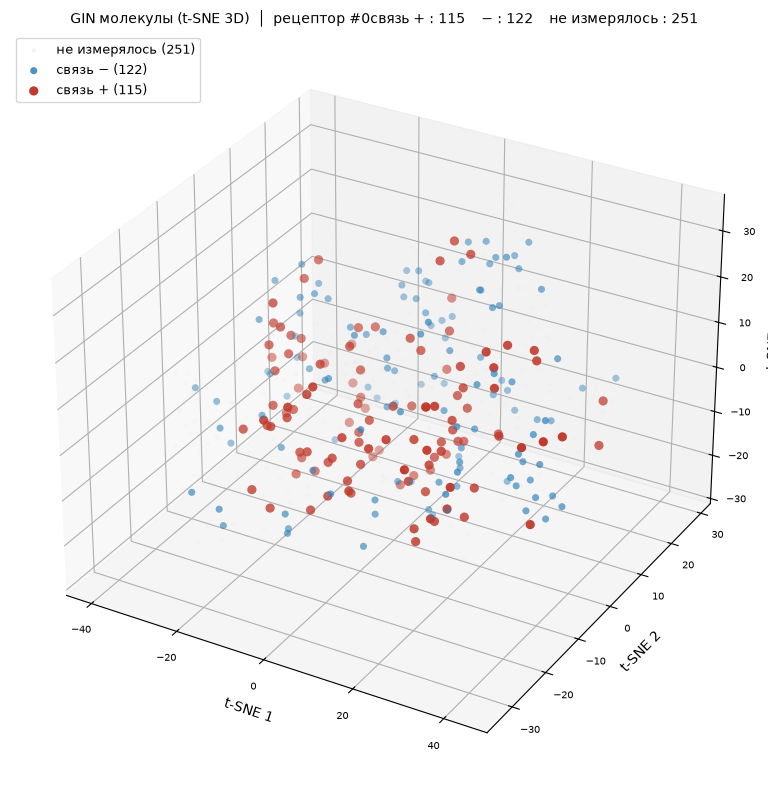

saved → mol_screen_receptor0.png


In [17]:
# --- 3D scatter: раскраска по выбранному рецептору --------------------------
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

RECEPTOR_IDX = 0          # <<< меняй номер рецептора здесь

seq  = RSTAT.loc[RECEPTOR_IDX, 'receptor']
sub  = PAIRS[PAIRS['receptor'] == seq]
lab  = dict(zip(sub['inchikey'], sub['label']))
codes = np.array([lab.get(m, -1) for m in MOLS])      # 1 = +, 0 = −, -1 = не измерялось

# рисуем в порядке: фон (неизмерено) → негативы → позитивы (сверху)
GROUPS = [(-1, '#d8d8d8', 10, 0.30, 'не измерялось'),
          ( 0, '#2c7fb8', 26, 0.85, 'связь −'),
          ( 1, '#c0392b', 44, 1.00, 'связь +')]

fig = plt.figure(figsize=(11, 8))
ax  = fig.add_subplot(111, projection='3d')
for c, col, s, al, name in GROUPS:
    m = codes == c
    ax.scatter(PROJ[m, 0], PROJ[m, 1], PROJ[m, 2], c=col, s=s, alpha=al,
               edgecolors='none', label=f'{name} ({int(m.sum())})', depthshade=True)

n_pos, n_neg, n_unm = int((codes == 1).sum()), int((codes == 0).sum()), int((codes == -1).sum())
ax.set_title(f'GIN молекулы (t-SNE 3D)  │  рецептор #{RECEPTOR_IDX}'
             f'связь + : {n_pos}    − : {n_neg}    не измерялось : {n_unm}', fontsize=10)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2'); ax.set_zlabel('t-SNE 3')
ax.legend(loc='upper left', fontsize=9); ax.tick_params(labelsize=7)
fig.tight_layout()
fname = FIG / f'mol_screen_receptor{RECEPTOR_IDX}.png'
fig.savefig(fname, dpi=140, bbox_inches='tight')
plt.show()
print('saved →', fname.name)

In [18]:
# --- Насколько предсказуемо связывание из ОДНОЙ химии (GIN) для рецептора ----
# XGBoost на сыром GIN (300-d), таргет = label, рецептор фиксирован.
# Стратифицированная 5-fold CV (out-of-fold), т.к. выборка на 1 рецептор мала.
# AUPRC база = pos_rate; AUPRC_lift = AUPRC / pos_rate.
from sklearn.model_selection import StratifiedKFold
from orbind.baselines import train_boost

def cv_boost_receptor(idx, folds=5, seed=42):
    seq = RSTAT.loc[idx, 'receptor']
    sub = PAIRS[PAIRS['receptor'] == seq]
    Xr  = np.stack([GIN[i] for i in sub['inchikey']]).astype(np.float32)
    yr  = sub['label'].to_numpy(np.float32)
    if yr.sum() < folds or (len(yr) - yr.sum()) < folds:
        return None                                  # слишком мал minority-класс для CV
    oof = np.zeros(len(yr))
    for tr, te in StratifiedKFold(folds, shuffle=True, random_state=seed).split(Xr, yr):
        oof[te] = train_boost(Xr[tr], yr[tr], Xr[te], seed=seed)
    m = D.metrics(yr, oof)
    return {'idx': idx, 'n': len(yr), 'n_pos': int(yr.sum()),
            'pos_rate': round(float(yr.mean()), 3),
            'AUROC': round(m['AUROC'], 3), 'AUPRC': round(m['AUPRC'], 3),
            'MCC': round(m['MCC'], 3), 'F1': round(m['F1'], 3)}

# текущий рецептор + сравнение по интересным номерам
CANDS = sorted({RECEPTOR_IDX, 0, 1, 2, 4, 5, 6, 12})
tab = pd.DataFrame([r for r in (cv_boost_receptor(i) for i in CANDS) if r]).set_index('idx')
tab['AUPRC_lift'] = (tab['AUPRC'] / tab['pos_rate']).round(2)
print('GIN-only XGBoost, 5-fold CV — предсказуемость связывания на рецептор:')
display(tab.sort_values('AUROC', ascending=False))
print('Узко-настроенные (низкий pos_rate) обычно предсказуемее — активы химически когерентны;')
print('широко-настроенные/сбалансированные труднее (разные хемотипы, +/- перемешаны).')
print('Оговорка: при очень малом minority-классе CV ненадёжна (AUROC может уйти <0.5).')

GIN-only XGBoost, 5-fold CV — предсказуемость связывания на рецептор:


,n,n_pos,pos_rate,AUROC,AUPRC,MCC,F1,AUPRC_lift
idx,,,,,,,,
12,185,22,0.119,0.904,0.781,0.733,0.762,6.56
6,161,28,0.174,0.890,0.626,0.524,0.607,3.60
4,257,52,0.202,0.821,0.662,0.516,0.593,3.28
1,120,82,0.683,0.815,0.917,0.400,0.824,1.34
5,122,34,0.279,0.753,0.637,0.362,0.537,2.28
0,237,115,0.485,0.697,0.646,0.223,0.603,1.33
2,123,63,0.512,0.696,0.665,0.349,0.688,1.30


Узко-настроенные (низкий pos_rate) обычно предсказуемее — активы химически когерентны;
широко-настроенные/сбалансированные труднее (разные хемотипы, +/- перемешаны).
Оговорка: при очень малом minority-классе CV ненадёжна (AUROC может уйти <0.5).


---
## Карта всех рецепторов: количество данных × лёгкость предсказания

Для каждого рецептора — GIN-only XGBoost (5-fold CV, адаптивно 3 при малом
minority-классе). Считается скриптом `scripts/modeling/per_receptor_gin_cv.py`
(кэш: `notebooks/cache/per_receptor_gin_cv.csv`). Ячейка ниже строит распределения.

рецепторов: 409  |  оценено CV: 160  |  мало данных: 249
AUROC: median=0.501  доля>0.7=0.21  доля>0.8=0.12


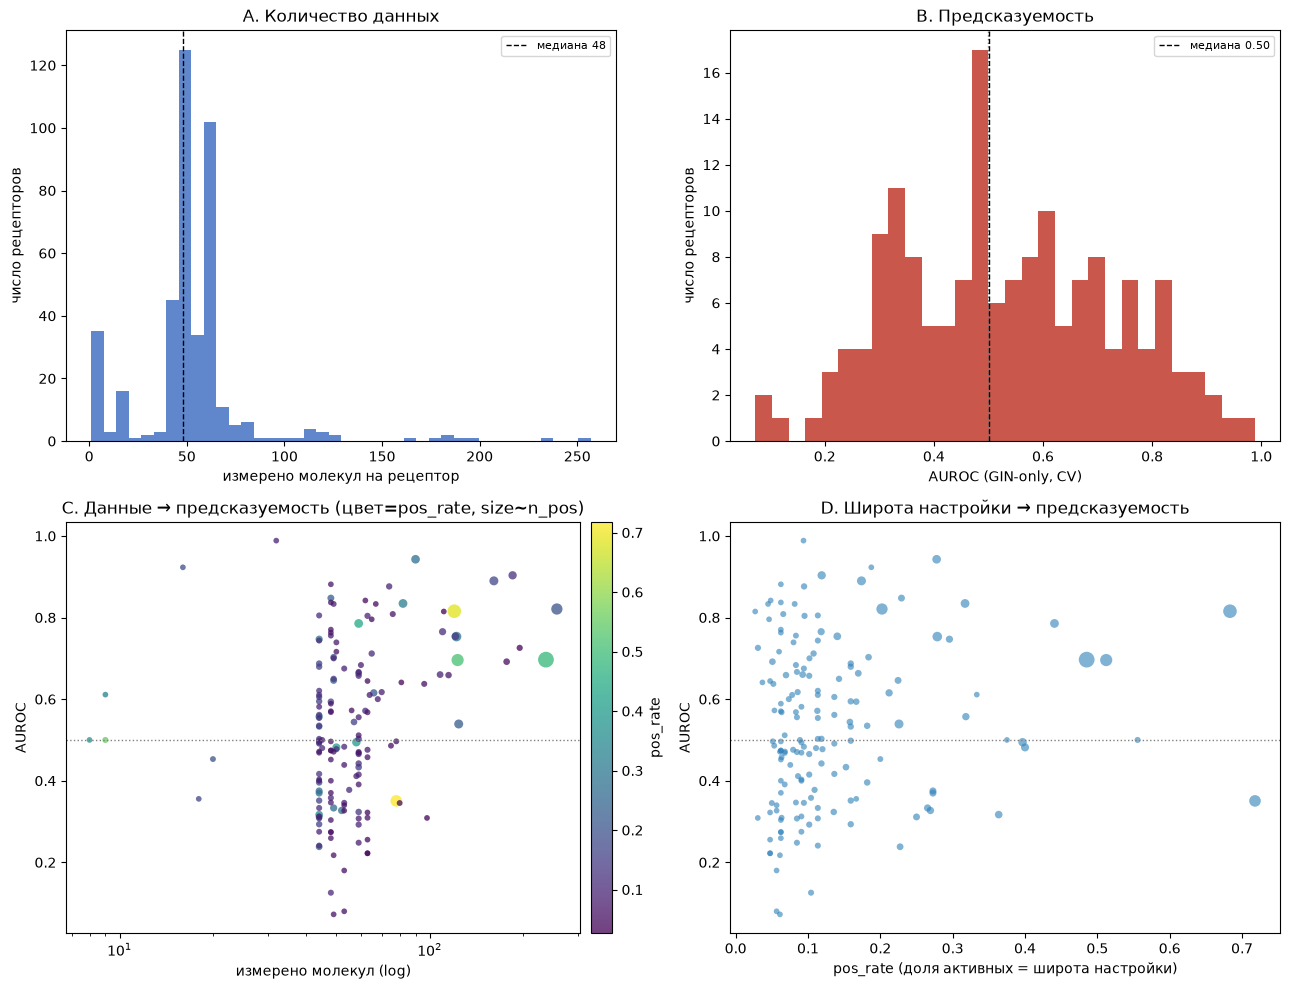

saved → per_receptor_gin_cv_map.png


In [19]:
# --- распределение рецепторов по данным и предсказуемости -------------------
_csv = ROOT / 'notebooks' / 'cache' / 'per_receptor_gin_cv.csv'
if not _csv.exists():
    print('нет', _csv.name, '— запусти scripts/modeling/per_receptor_gin_cv.py')
else:
    DF = pd.read_csv(_csv)
    EV = DF[DF['folds'] > 0].copy()             # рецепторы, где CV возможна
    print(f"рецепторов: {len(DF)}  |  оценено CV: {len(EV)}  |  мало данных: {int((DF.folds==0).sum())}")
    print(f"AUROC: median={EV.AUROC.median():.3f}  доля>0.7={(EV.AUROC>0.7).mean():.2f}  "
          f"доля>0.8={(EV.AUROC>0.8).mean():.2f}")

    fig, ax = plt.subplots(2, 2, figsize=(13, 10))

    # A: сколько молекул измерено на рецептор (количество данных)
    ax[0,0].hist(DF['n'], bins=40, color='#4472C4', alpha=0.85)
    ax[0,0].axvline(DF['n'].median(), c='k', ls='--', lw=1, label=f"медиана {int(DF['n'].median())}")
    ax[0,0].set_xlabel('измерено молекул на рецептор'); ax[0,0].set_ylabel('число рецепторов')
    ax[0,0].set_title('A. Количество данных'); ax[0,0].legend(fontsize=8)

    # B: распределение AUROC (лёгкость предсказания)
    ax[0,1].hist(EV['AUROC'], bins=30, color='#c0392b', alpha=0.85)
    ax[0,1].axvline(0.5, c='gray', ls=':', lw=1)
    ax[0,1].axvline(EV['AUROC'].median(), c='k', ls='--', lw=1, label=f"медиана {EV.AUROC.median():.2f}")
    ax[0,1].set_xlabel('AUROC (GIN-only, CV)'); ax[0,1].set_ylabel('число рецепторов')
    ax[0,1].set_title('B. Предсказуемость'); ax[0,1].legend(fontsize=8)

    # C: данные vs предсказуемость, цвет = pos_rate
    sc = ax[1,0].scatter(EV['n'], EV['AUROC'], c=EV['pos_rate'], cmap='viridis',
                         s=14 + EV['n_pos'], alpha=0.75, edgecolors='none')
    ax[1,0].axhline(0.5, c='gray', ls=':', lw=1)
    ax[1,0].set_xscale('log'); ax[1,0].set_xlabel('измерено молекул (log)')
    ax[1,0].set_ylabel('AUROC'); ax[1,0].set_title('C. Данные → предсказуемость (цвет=pos_rate, size~n_pos)')
    fig.colorbar(sc, ax=ax[1,0], fraction=0.045, pad=0.02, label='pos_rate')

    # D: широта настройки (pos_rate) vs предсказуемость
    ax[1,1].scatter(EV['pos_rate'], EV['AUROC'], s=14 + EV['n_pos'],
                    c='#2c7fb8', alpha=0.6, edgecolors='none')
    ax[1,1].axhline(0.5, c='gray', ls=':', lw=1)
    ax[1,1].set_xlabel('pos_rate (доля активных = широта настройки)')
    ax[1,1].set_ylabel('AUROC'); ax[1,1].set_title('D. Широта настройки → предсказуемость')

    fig.tight_layout()
    fig.savefig(FIG / 'per_receptor_gin_cv_map.png', dpi=140, bbox_inches='tight')
    plt.show()
    print('saved →', 'per_receptor_gin_cv_map.png')